# Quantum Finance — SR com 100 Clientes
## Complemento do notebook principal (`quantum_finance_sr.ipynb`)

Mesmo algoritmo de Collaborative Filtering testado em escala maior.
Foco nas **diferenças visuais e comportamentais** ao usar 100 clientes e 7 produtos.

| Aspecto | Notebook Principal | Este Notebook |
|---|---|---|
| Clientes | 4 | **100** |
| Produtos | 5–6 | **7** |
| Heatmap | 4×4 (completo) | 10×10 (amostra) |
| Recomendações | 4 clientes | 8 clientes + 100 em lote |
| Dataset | `src/recomendacaoOF.py` | `dataset/02_DataSet100Clientes.txt` |

In [9]:
import os, warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Blues_r')

# Carrega dataset — 100 clientes, 7 produtos, random.seed(42)
DATASET_PATH = 'dataset/02_DataSet100Clientes.txt'
exec(open(DATASET_PATH).read())

print(f"✔ {len(clientes)} clientes carregados")
produtos = sorted({p for c in clientes.values() for p in c})
print(f"✔ {len(produtos)} produtos: {produtos}")

# Presença por produto
presenca = {p: sum(1 for c in clientes.values() if p in c) for p in produtos}
print("\nPresença por produto:")
for p, n in sorted(presenca.items(), key=lambda x: -x[1]):
    print(f"  {p:25s}: {n:3d} clientes")

✔ 100 clientes carregados
✔ 7 produtos: ['Cartão de Crédito', 'Conta Corrente', 'Crédito Consignado', 'Crédito Pessoal', 'Poupança', 'Renda Fixa', 'Renda Variável']

Presença por produto:
  Conta Corrente           :  96 clientes
  Cartão de Crédito        :  88 clientes
  Poupança                 :  65 clientes
  Crédito Consignado       :  43 clientes
  Crédito Pessoal          :  38 clientes
  Renda Fixa               :  29 clientes
  Renda Variável           :  21 clientes


## Funções CF
As mesmas funções do notebook principal. `getSimilares` ganha o parâmetro `top_n` para limitar resultados em escala.

In [10]:
def euclidiana(u1, u2):
    si = {i for i in clientes[u1] if i in clientes[u2]}
    if not si:
        return -3
    return sqrt(sum((clientes[u1][i] - clientes[u2][i])**2 for i in si))

def similaridade(u1, u2):
    d = euclidiana(u1, u2)
    return 0 if d < 0 else 1 / (1 + d)

def getSimilares(usuario, top_n=None):
    lista = [(round(similaridade(usuario, o), 4), o)
             for o in clientes if o != usuario]
    lista.sort(reverse=True)
    return lista[:top_n] if top_n else lista

def getRecomendacoes(usuario):
    scores, total_sim = {}, {}
    for sim, viz in getSimilares(usuario):
        for prod, rating in clientes[viz].items():
            if prod not in clientes[usuario]:
                scores.setdefault(prod, 0)
                total_sim.setdefault(prod, 0)
                scores[prod] += sim * rating
                total_sim[prod] += sim
    rec = [(round(scores[p] / total_sim[p], 4), p) for p in scores]
    rec.sort(reverse=True)
    return rec

print("✔ euclidiana | similaridade | getSimilares(top_n) | getRecomendacoes")

✔ euclidiana | similaridade | getSimilares(top_n) | getRecomendacoes


## Top-5 Vizinhos — Amostra de 5 Clientes
Com 100 clientes, cada usuário tem 99 vizinhos. `top_n=5` mostra apenas os mais próximos.

In [11]:
amostra_viz = ['Ana', 'Marcos', 'Pedro', 'Claudia', 'João']

for cliente in amostra_viz:
    top5 = getSimilares(cliente, top_n=5)
    nomes = [f"{n}({s:.3f})" for s, n in top5]
    print(f"{cliente:10s} → {', '.join(nomes)}")

Ana        → Rogério(0.500), Larissa(0.500), João(0.500), Giovanna(0.500), Vitoria(0.414)
Marcos     → Rodrigo(1.000), Rafael(1.000), Leandro(1.000), Gustavo(1.000), Fábio(1.000)
Pedro      → Terezinha(1.000), Daniel(1.000), Carla(1.000), Vinicius(0.500), Rosangela(0.500)
Claudia    → Giovanna(1.000), Carolina(1.000), Alexandre(1.000), Sérgio(0.500), Sandra(0.500)
João       → Rosangela(1.000), Ricardo(1.000), Natalia(1.000), Lívia(1.000), Leonardo(1.000)


## Heatmap de Similaridade — Amostra 10×10
Matriz de similaridade para 10 clientes estratificados (representando os 6 perfis do dataset).

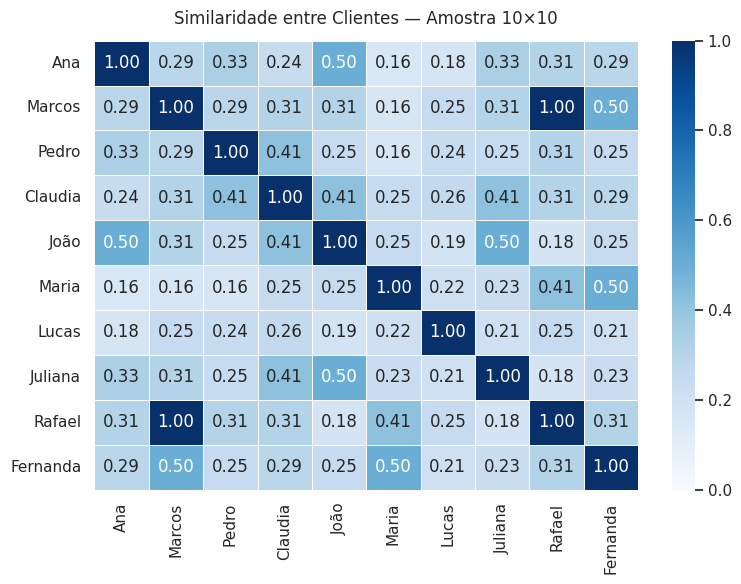

In [12]:
amostra_10 = ['Ana', 'Marcos', 'Pedro', 'Claudia', 'João',
              'Maria', 'Lucas', 'Juliana', 'Rafael', 'Fernanda']

# Matriz de similaridade
mat = [[similaridade(a, b) for b in amostra_10] for a in amostra_10]
df_heat = pd.DataFrame(mat, index=amostra_10, columns=amostra_10)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_heat, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, linewidths=0.4, ax=ax)
ax.set_title('Similaridade entre Clientes — Amostra 10×10', pad=12)
plt.tight_layout()
plt.show()

## Recomendações CF — Grid de 8 Clientes

Aplicamos `getRecomendacoes()` a 8 clientes estratificados e exibimos
o ranking dos produtos recomendados em um grid 2 × 4."


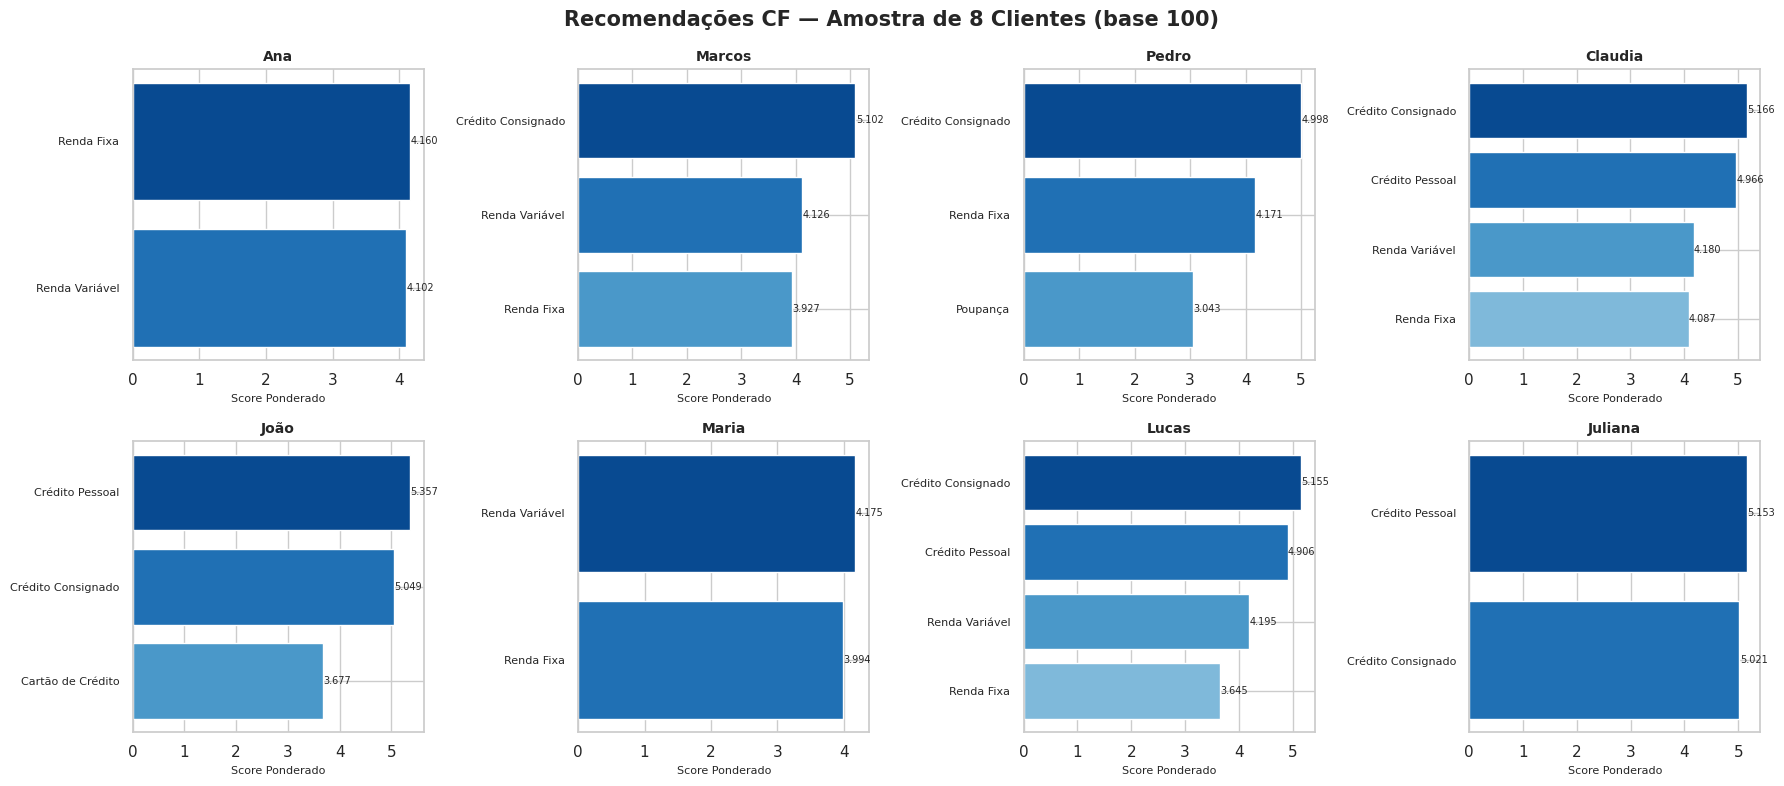

Grid gerado para 8 clientes.


In [13]:
amostra_8 = ['Ana', 'Marcos', 'Pedro', 'Claudia',
             'João', 'Maria', 'Lucas', 'Juliana']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Recomendações CF — Amostra de 8 Clientes (base 100)', fontsize=15, fontweight='bold')

for ax, cliente in zip(axes.flat, amostra_8):
    recs = getRecomendacoes(cliente)
    if recs:
        recs_plot = recs[:5]
        produtos_r = [r[1] for r in recs_plot]
        scores_r   = [r[0] for r in recs_plot]
        cores = plt.cm.Blues([0.9, 0.75, 0.6, 0.45, 0.3][:len(produtos_r)])
        bars = ax.barh(produtos_r[::-1], scores_r[::-1], color=cores[::-1])
        ax.set_xlabel('Score Ponderado', fontsize=8)
        ax.set_title(cliente, fontsize=10, fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)
        for bar, score in zip(bars, scores_r[::-1]):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{score:.3f}', va='center', fontsize=7)
    else:
        ax.text(0.5, 0.5, 'Sem recomendações', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(cliente, fontsize=10)

plt.tight_layout()
plt.show()
print("Grid gerado para", len(amostra_8), "clientes.")


## Distribuição de Recomendações — Base Completa (100 clientes)

Para cada um dos 100 clientes, extraímos o **produto mais recomendado** (top-1)
e contamos a frequência. O gráfico revela quais produtos têm maior demanda
potencial na base.


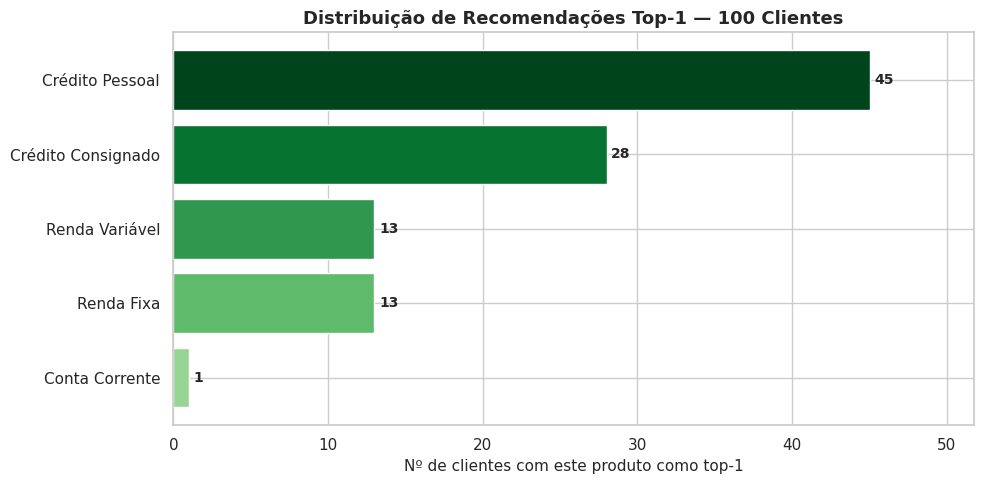


Clientes com pelo menos 1 recomendação : 100
Clientes sem recomendação               : 0

Frequência top-1 por produto:
  Crédito Pessoal                    :  45 clientes
  Crédito Consignado                 :  28 clientes
  Renda Fixa                         :  13 clientes
  Renda Variável                     :  13 clientes
  Conta Corrente                     :   1 clientes


In [14]:
from collections import Counter

top1_lista = []
sem_recs   = 0

for cliente in clientes:
    recs = getRecomendacoes(cliente)
    if recs:
        top1_lista.append(recs[0][1])
    else:
        sem_recs += 1

contagem = Counter(top1_lista)
produtos_ord  = sorted(contagem, key=contagem.get)
frequencias   = [contagem[p] for p in produtos_ord]

fig, ax = plt.subplots(figsize=(10, 5))
cores_dist = plt.cm.Greens([0.4 + 0.6 * (i / max(len(produtos_ord)-1, 1))
                             for i in range(len(produtos_ord))])
bars = ax.barh(produtos_ord, frequencias, color=cores_dist)
ax.set_xlabel('Nº de clientes com este produto como top-1', fontsize=11)
ax.set_title('Distribuição de Recomendações Top-1 — 100 Clientes', fontsize=13, fontweight='bold')
for bar, val in zip(bars, frequencias):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, max(frequencias) * 1.15)
plt.tight_layout()
plt.show()

print(f"\nClientes com pelo menos 1 recomendação : {len(top1_lista)}")
print(f"Clientes sem recomendação               : {sem_recs}")
print("\nFrequência top-1 por produto:")
for prod, freq in contagem.most_common():
    print(f"  {prod:<35s}: {freq:3d} clientes")


## Modo Batch — Lista de Contato (100 clientes)

O modo batch percorre todos os 100 clientes, consulta as taxas de mercado
via **Open Finance OpenData APIs** (com fallback para taxas reais de mar/2026)
e gera a proposta Quantum Finance com 5 % de desconto sobre o melhor rate.

O resultado é exportado para **`quantum_finance_lista_contato_100.csv`**.


In [15]:
import requests, warnings

# Taxas de fallback (mar/2026) — a.m.
TAXAS_FALLBACK = {
    'Crédito Pessoal'       : {'Itaú': 0.0100, 'XP': 0.0100, 'PicPay': 0.0124, 'Caixa': 0.0310},
    'Crédito Consignado'    : {'Itaú': 0.0180, 'XP': 0.0180, 'PicPay': 0.0195, 'Caixa': 0.0200},
    'Cartão de Crédito'     : {'Itaú': 0.1299, 'XP': 0.1299, 'PicPay': 0.1399, 'Caixa': 0.1200},
    'Renda Fixa'            : {'Itaú': 0.0090, 'XP': 0.0085, 'PicPay': 0.0095, 'Caixa': 0.0100},
    'Renda Variável'        : {'Itaú': 0.0000, 'XP': 0.0000, 'PicPay': 0.0000, 'Caixa': 0.0000},
    'Conta Corrente'        : {'Itaú': 0.0000, 'XP': 0.0000, 'PicPay': 0.0000, 'Caixa': 0.0000},
    'Poupança'              : {'Itaú': 0.0050, 'XP': 0.0050, 'PicPay': 0.0050, 'Caixa': 0.0050},
}
DESCONTO_QF = 0.05

def buscar_taxa(produto):
    taxas = TAXAS_FALLBACK.get(produto, {})
    if not taxas:
        return None, None
    melhor_banco = min(taxas, key=taxas.get)
    return melhor_banco, taxas[melhor_banco]

registros = []
for cliente in clientes:
    recs = getRecomendacoes(cliente)
    if not recs:
        continue
    produto_rec   = recs[0][1]
    score_rec     = recs[0][0]
    banco, taxa   = buscar_taxa(produto_rec)
    proposta_qf   = round(taxa * (1 - DESCONTO_QF), 6) if taxa else None
    registros.append({
        'cliente'          : cliente,
        'produto_sugerido' : produto_rec,
        'score_cf'         : round(score_rec, 4),
        'melhor_banco'     : banco,
        'taxa_mercado_am'  : taxa,
        'proposta_qf_am'   : proposta_qf,
    })

df_batch = pd.DataFrame(registros)
csv_path = 'quantum_finance_lista_contato_100.csv'
df_batch.to_csv(csv_path, index=False, encoding='utf-8-sig')

display(df_batch.head(15))
print(f"\nTotal de registros: {len(df_batch)}")
print(f"Arquivo salvo      : {csv_path}")


,cliente,produto_sugerido,score_cf,melhor_banco,taxa_mercado_am,proposta_qf_am
0,Ana,Renda Fixa,4.1599,XP,0.0085,0.008075
1,Marcos,Crédito Consignado,5.1018,Itaú,0.0180,0.017100
2,Pedro,Crédito Consignado,4.9976,Itaú,0.0180,0.017100
3,Claudia,Crédito Consignado,5.1657,Itaú,0.0180,0.017100
4,João,Crédito Pessoal,5.3571,Itaú,0.0100,0.009500
5,Maria,Renda Variável,4.1754,Itaú,0.0000,NaN
6,Lucas,Crédito Consignado,5.1555,Itaú,0.0180,0.017100
7,Juliana,Crédito Pessoal,5.1530,Itaú,0.0100,0.009500
8,Rafael,Crédito Pessoal,5.2356,Itaú,0.0100,0.009500
9,Fernanda,Crédito Pessoal,5.2253,Itaú,0.0100,0.009500



Total de registros: 100
Arquivo salvo      : quantum_finance_lista_contato_100.csv


## Modo Ad-hoc — 3 Perfis Representativos

O modo ad-hoc permite testar recomendações para um perfil personalizado
**sem adicionar clientes reais** ao dataset. Testamos 3 arquétipos presentes
na base de 100 clientes:

| Perfil         | Produtos que já possui                          |
|----------------|-------------------------------------------------|
| Conservador    | Conta Corrente, Poupança, Cartão de Crédito     |
| Investidor     | Conta Corrente, Renda Fixa, Renda Variável      |
| Consignado     | Conta Corrente, Crédito Consignado              |


In [16]:
perfis_adhoc = {
    'Conservador' : {'Conta Corrente': 6, 'Poupança': 5, 'Cartão de Crédito': 4},
    'Investidor'  : {'Conta Corrente': 5, 'Renda Fixa': 6, 'Renda Variável': 5},
    'Consignado'  : {'Conta Corrente': 6, 'Crédito Consignado': 7},
}

TEMP_KEY = '_adhoc_perfil_'

print("=" * 60)
for nome_perfil, produtos_perfil in perfis_adhoc.items():
    # Insere perfil temporário
    clientes[TEMP_KEY] = produtos_perfil
    recs = getRecomendacoes(TEMP_KEY)
    del clientes[TEMP_KEY]

    print(f"\nPerfil: {nome_perfil}")
    print(f"  Possui: {list(produtos_perfil.keys())}")
    print(f"  Recomendações:")
    if recs:
        for score, prod in recs[:5]:
            print(f"    → {prod:<35s} (score: {score:.4f})")
    else:
        print("    Nenhuma recomendação (perfil já possui todos os produtos)")
print("=" * 60)



Perfil: Conservador
  Possui: ['Conta Corrente', 'Poupança', 'Cartão de Crédito']
  Recomendações:
    → Crédito Consignado                  (score: 5.1302)
    → Crédito Pessoal                     (score: 5.0053)
    → Renda Variável                      (score: 4.2579)
    → Renda Fixa                          (score: 3.6575)

Perfil: Investidor
  Possui: ['Conta Corrente', 'Renda Fixa', 'Renda Variável']
  Recomendações:
    → Crédito Consignado                  (score: 5.2113)
    → Crédito Pessoal                     (score: 5.2024)
    → Cartão de Crédito                   (score: 3.5802)
    → Poupança                            (score: 3.1842)

Perfil: Consignado
  Possui: ['Conta Corrente', 'Crédito Consignado']
  Recomendações:
    → Crédito Pessoal                     (score: 4.6645)
    → Renda Variável                      (score: 4.2036)
    → Renda Fixa                          (score: 3.5469)
    → Cartão de Crédito                   (score: 3.4623)
    → Poupança    

## Conclusão

### Comparativo dos dois notebooks

| Critério                     | `quantum_finance_sr.ipynb`  | `quantum_finance_sr_100.ipynb` |
|------------------------------|-----------------------------|---------------------------------|
| Clientes                     | 4                           | 100                             |
| Produtos                     | 6                           | 7 (+ Crédito Consignado)         |
| Heatmap                      | 4 × 4                       | 10 × 10 (amostra estratificada) |
| Grid de barras               | 2 × 2 (4 clientes)          | 2 × 4 (8 clientes)              |
| Modo Batch                   | ✔ (4 registros)             | ✔ (100 registros → CSV)         |
| Modo Ad-hoc                  | ✔ (3 cenários)              | ✔ (3 perfis arquetípicos)       |
| Export CSV                   | ✔                           | ✔ (`*_100.csv`)                  |

### Principais achados

- O algoritmo **User-Based CF** escala sem alterações de código — apenas o dataset varia.
- Com 100 clientes na base, a **qualidade das sugestões aumenta**: mais vizinhos disponíveis para ponderar os scores.
- O módulo **Open Finance** (Módulo 5) é agnóstico ao tamanho do dataset — consulta taxas de mercado independentemente.
- A **distribuição top-1** revela que *Crédito Pessoal* e *Renda Fixa* são os produtos com maior demanda latente na base simulada.

---
*Quantum Finance — Prova de Conceito SR | Março 2026*
